# Figure out the right way to preprocess

In [13]:
import numpy as np

In [14]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

In [15]:
# def load_data(gene_list, head=0, puck_list = "all"):
#     # Load the H5AD file
#     file_path = os.path.expanduser('~/project/mouse_ovary_slide_seq_young_estrus.h5ad')
#     adata = sc.read_h5ad(file_path)
#     if puck_list != "all":
#         adata = adata[adata.obs['puck'].isin(puck_list)]
        
#     # Extract spatial coordinates
#     coordinates = pd.DataFrame(adata.obsm["spatial"], columns=['x', 'y'], index=adata.obs_names)
#     # Extract gene expression levels
#     gene_data = [isolate_gene_values(adata, gene) for gene in gene_list]
#     # Combine to create df
#     df = pd.concat([coordinates] + gene_data, axis=1)

#     # Shuffle and sample the DataFrame
#     df = df.sample(frac=1)
#     if head!=0:
#         df = df.head(head)
    
#     # Preprocessing Step 1: Identify columns that sum to 0; drop those columns from df and from gene_list; divide the rest by their sums
#     column_sums = df[gene_list].sum()
#     zero_sum_columns = column_sums[column_sums == 0].index
#     if len(zero_sum_columns) > 0:
#         print(f"{list(zero_sum_columns)} dropped from gene_list due to not being observed.")
#         column_sums = column_sums.drop(zero_sum_columns)
#         df = df.drop(columns=zero_sum_columns)
#         gene_list = [col for col in gene_list if col not in zero_sum_columns]
#     # Divide each column by its corresponding sum
#     df[gene_list] = df[gene_list].div(column_sums, axis=1)

#     # Preprocessing Step 2: Divide 'x' and 'y' by 5000; log(1+x) the genes
#     df['x'] = df['x'] / 5000
#     df['y'] = df['y'] / 5000
#     for gene in gene_list:
#         df[gene] = np.log(df[gene]+1)

#     # Preprocessing Step 3: Make all standard deviations equal to 100
#     for gene in gene_list:
#         std = df[gene].std()
#         if std == 0:
#             print(f"error: {gene} has zero standard deviation")
#         else:
#             df[gene] = df[gene] / std * 10

#     # Output Objects
#     # Convert 'x' and 'y' columns into a tensor for spatial coordinates, X
#     X = torch.tensor(df[['x', 'y']].values, dtype=torch.float64)
#     # Convert gene columns into a tensor for gene expression values, Y
#     Y = torch.tensor(df[gene_list].values, dtype=torch.float64)
#     return adata, X, Y, df, gene_list

In [16]:
# # Global parameters:
number_of_cycles = 1 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 1
dims = 2  # 2D spatial
head = 0 # how many locations to consider in the real data set.

In [17]:
gene_list = ["Inha", "Esr1"]
gene_list = ["Inha"]
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
puck_list = ['Puck_230517_39'] # the largest puck
adata, X,Y,df, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)

['Lhb', 'Cga'] dropped from gene_list due to not being observed.


In [18]:
df

,x,y,Inha,Inhba,Inhbb,Fst,Esr1,Esr2,Pgr,Ar,...,Parm1,Akr1c18,Fshr,Star,Ptgfr,Sfrp4,Acvr1,Acvr2a,Acvr2b,Ghr
CACATAAAGAGCCA-1-2,0.61472,0.49994,0.000000,0.000000,0.0,16.657661,0.000000,24.736612,0.0,47.366367,...,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
AAANCCAGCGTGCC-1-2,0.68104,0.49862,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,23.691738,...,0.0,0.0,0.00000,9.405074,0.0,0.0,42.987991,0.0,0.0,67.957527
AGCAGTACAGACAC-1-2,0.50314,0.50642,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.00000,18.818993,0.0,0.0,0.000000,0.0,0.0,0.000000
GGTACATCCAATGC-1-2,0.52844,0.38400,3.022603,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.00000,9.405074,0.0,0.0,0.000000,0.0,0.0,0.000000
TTATCTCGATGTAG-1-2,0.66776,0.55458,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTAGCCAGGTCGGC-1-2,0.65620,0.49080,6.045053,0.000000,0.0,16.657661,0.000000,0.000000,0.0,23.691738,...,0.0,0.0,61.42865,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
AAGCCCTAAAACCG-1-2,0.82342,0.51756,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
AGTGGTAACGACCT-1-2,0.84852,0.69092,0.000000,6.988453,0.0,0.000000,0.000000,0.000000,0.0,23.691738,...,0.0,0.0,0.00000,47.024643,0.0,0.0,0.000000,0.0,0.0,0.000000
GATGACCCGAATGC-1-2,0.84162,0.69608,0.000000,0.000000,0.0,0.000000,38.041447,0.000000,0.0,0.000000,...,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


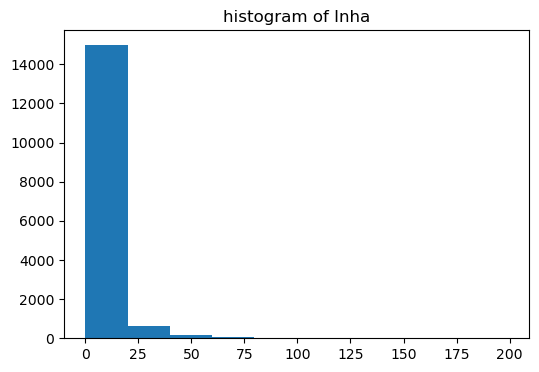

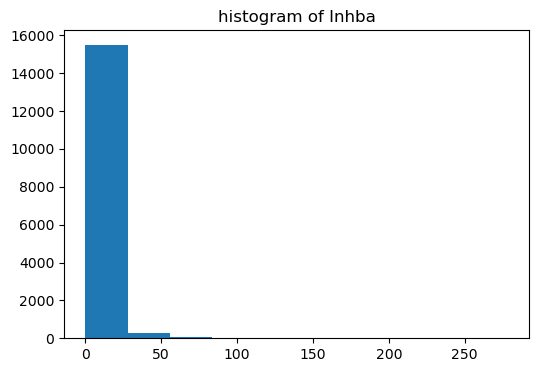

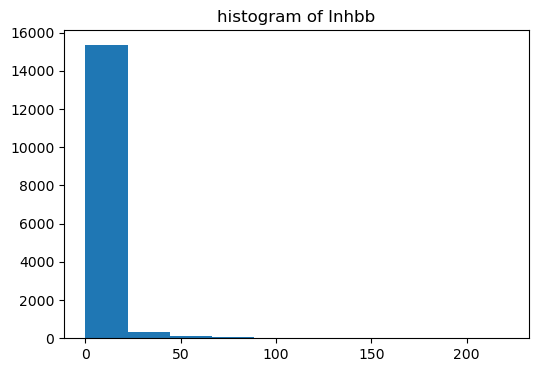

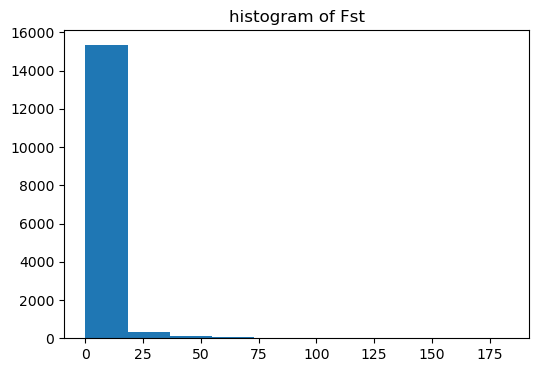

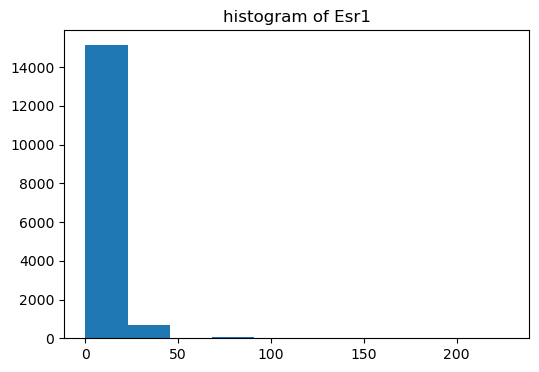

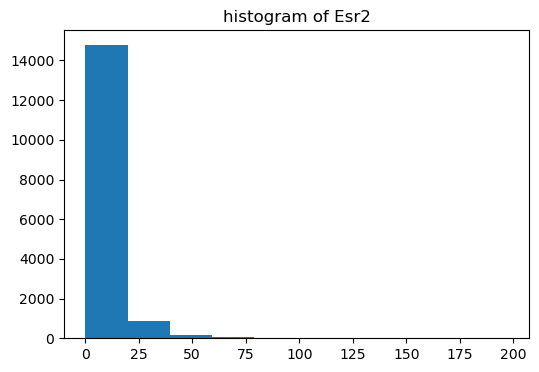

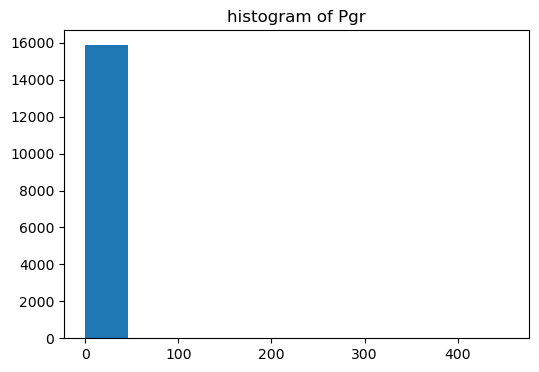

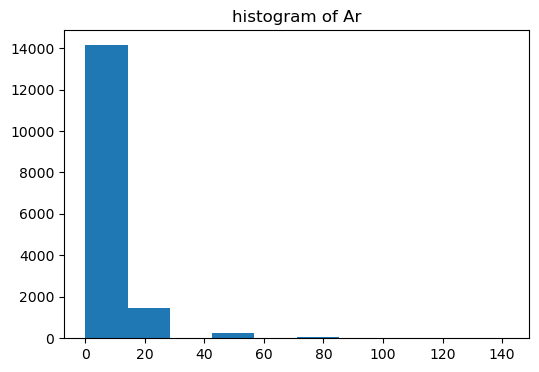

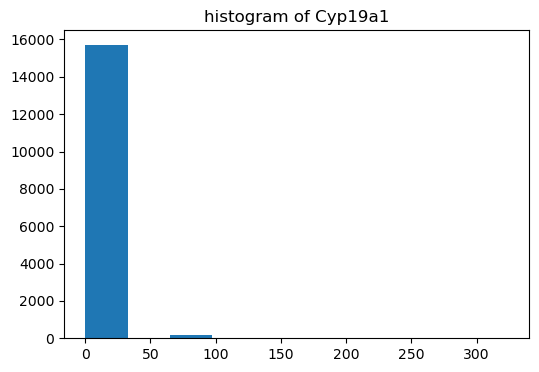

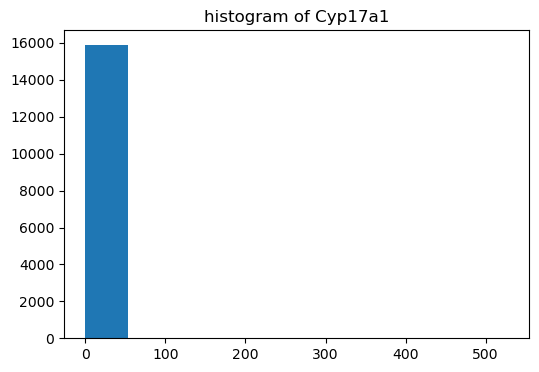

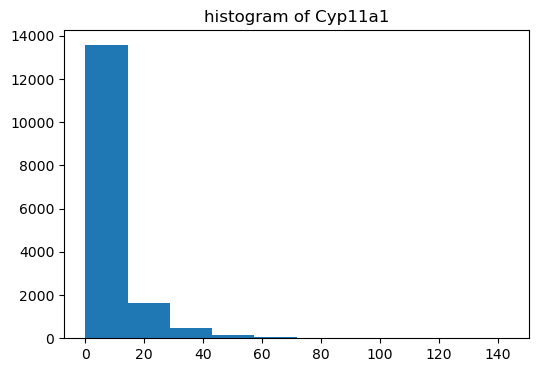

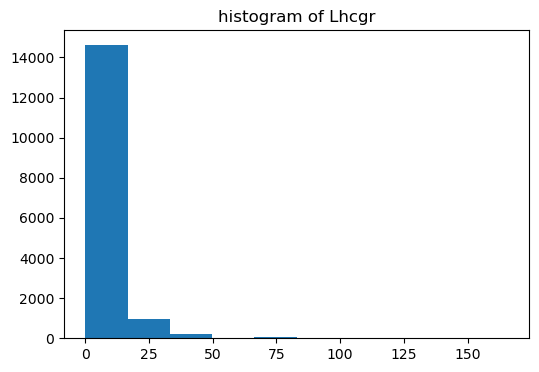

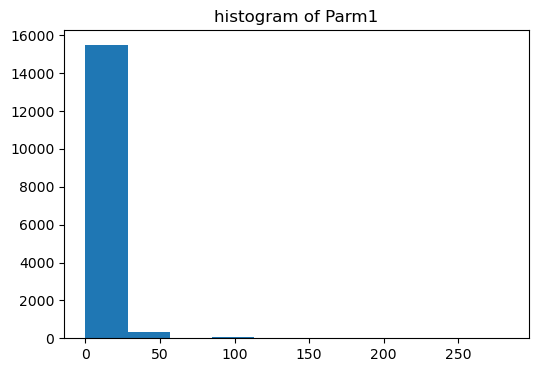

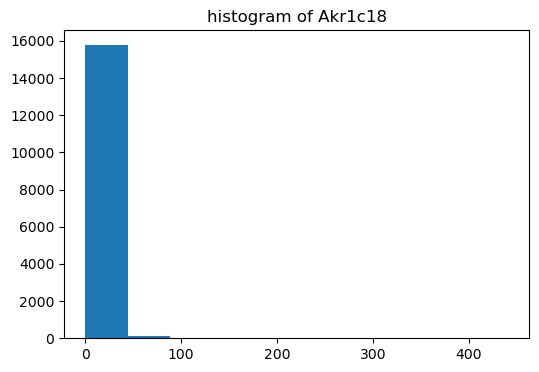

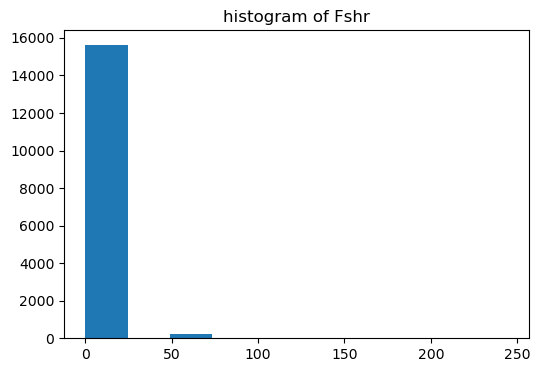

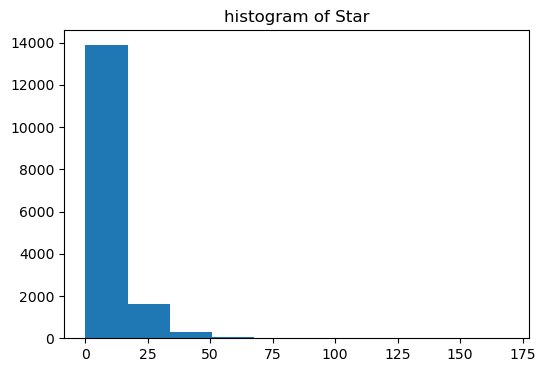

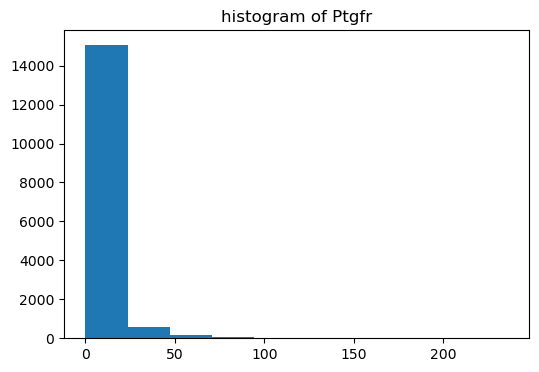

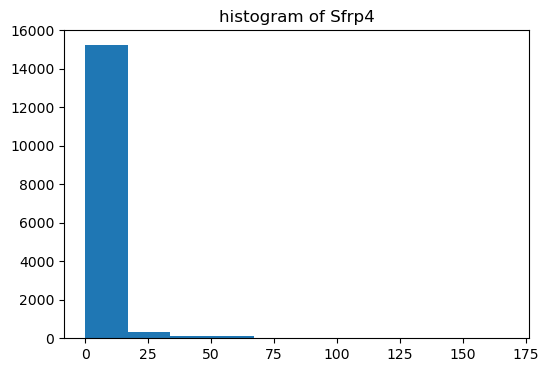

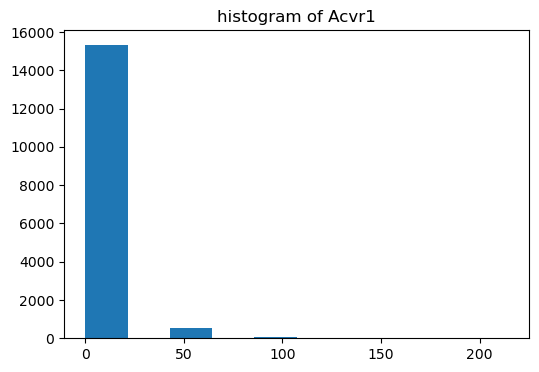

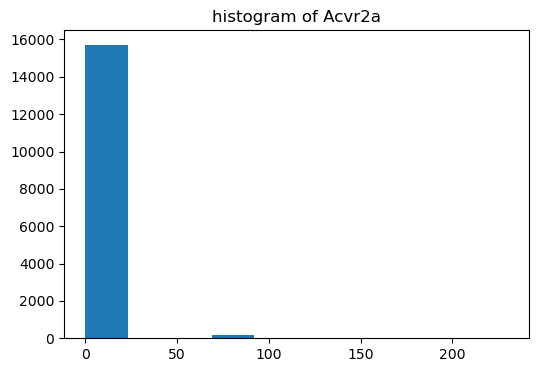

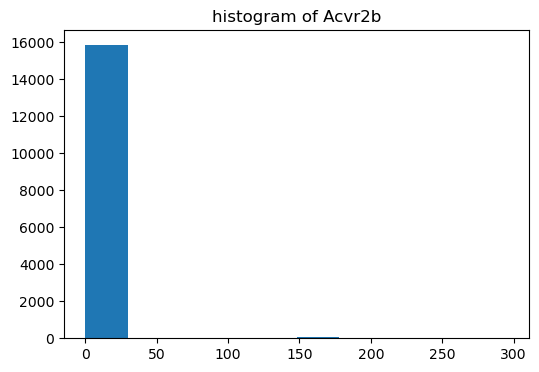

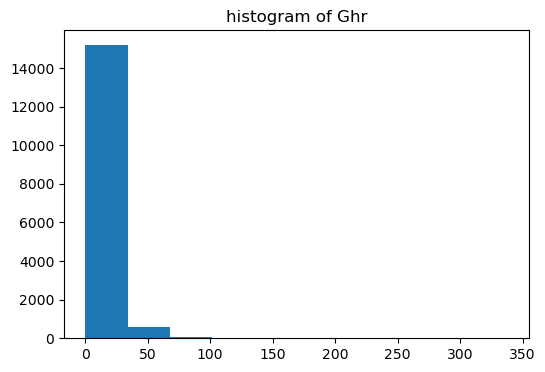

In [19]:
# Plot scatter plots for each gene in gene_list
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    plt.hist(df[gene])
    plt.title(f"histogram of {gene}")
    plt.show()

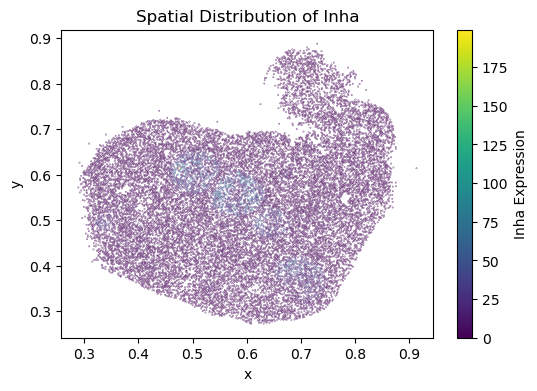

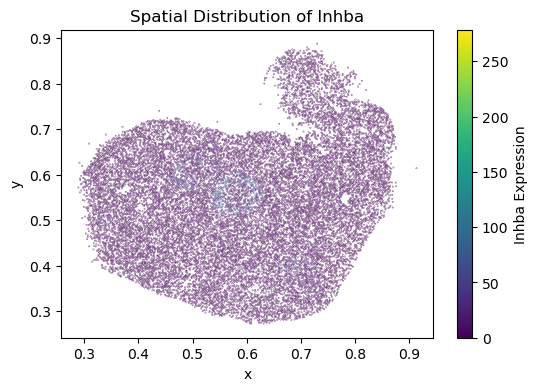

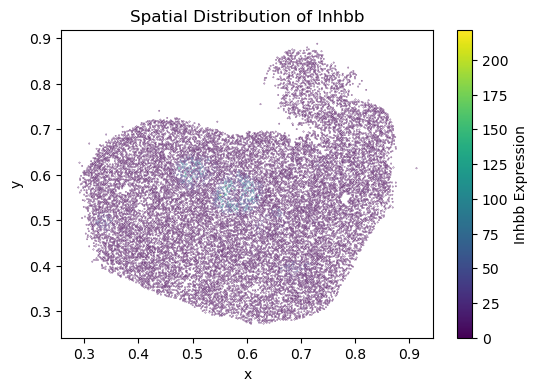

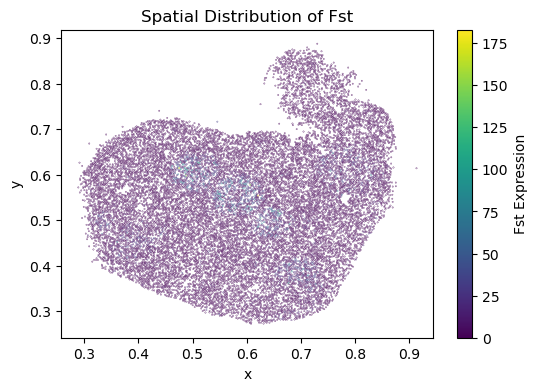

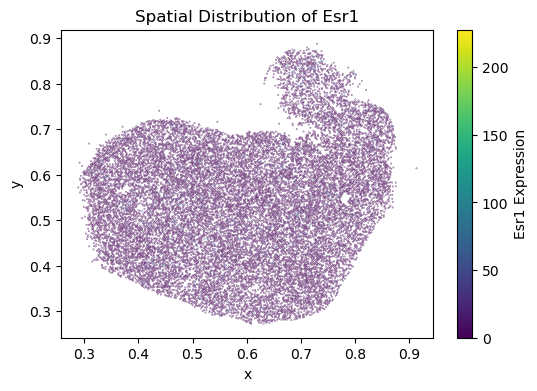

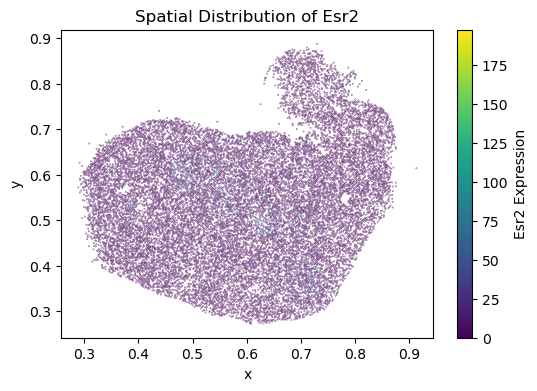

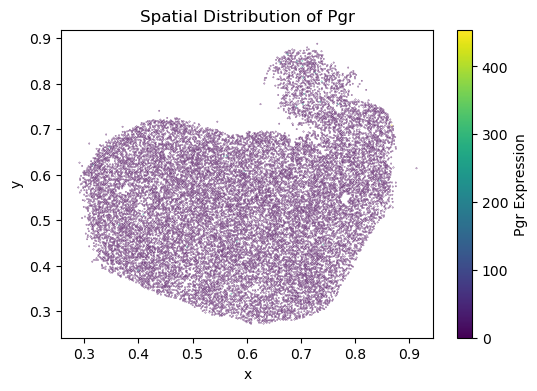

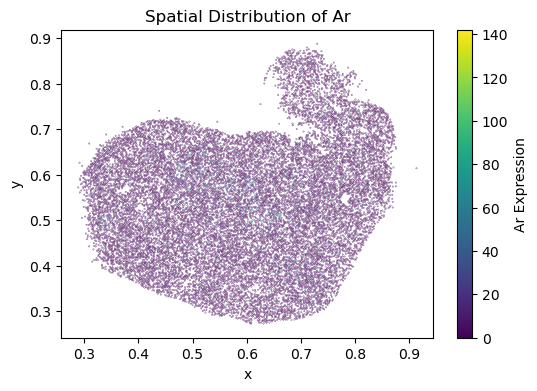

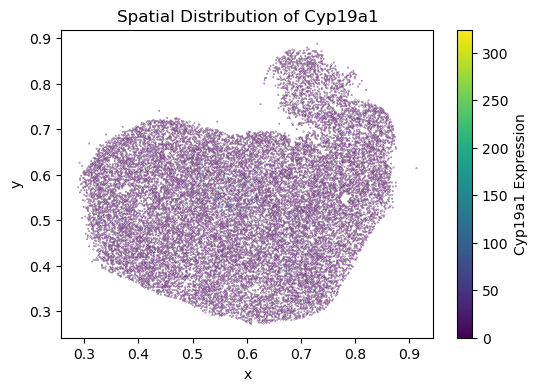

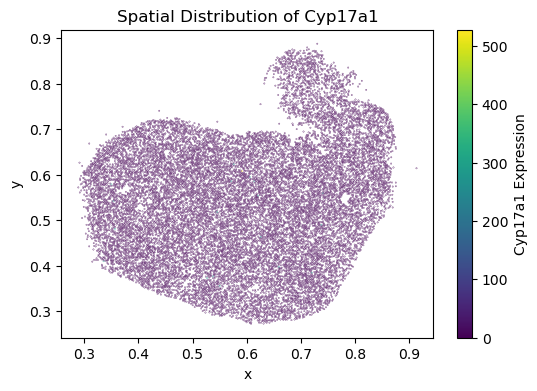

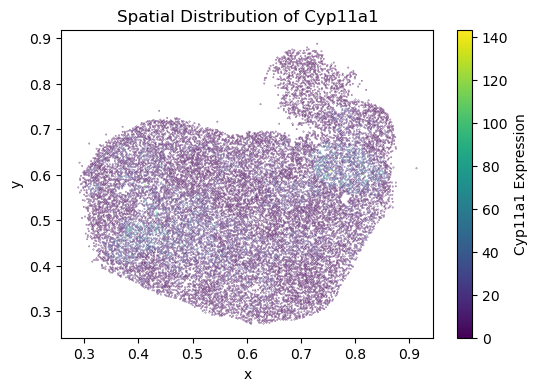

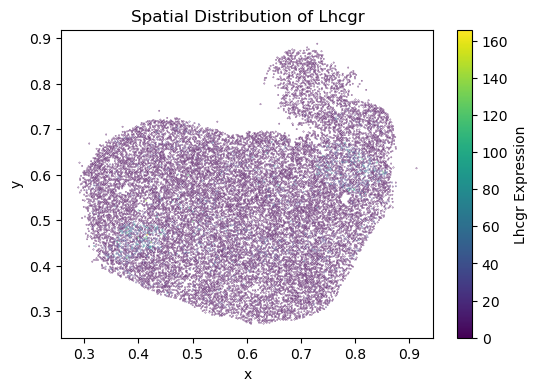

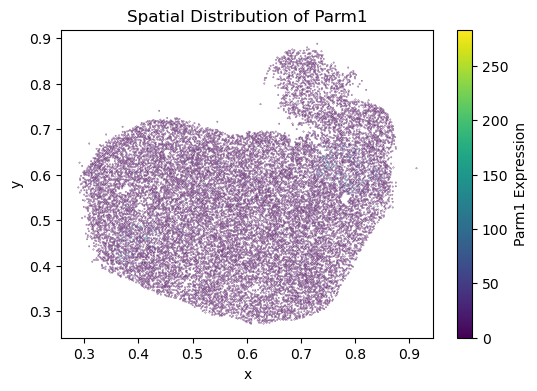

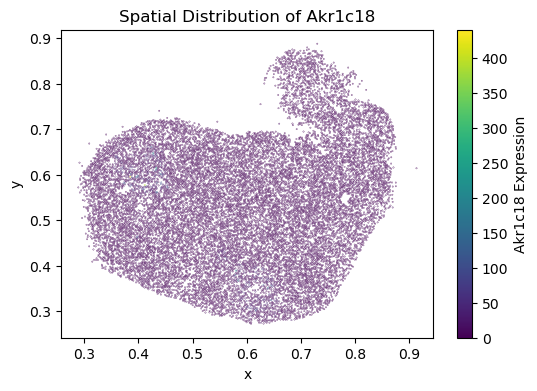

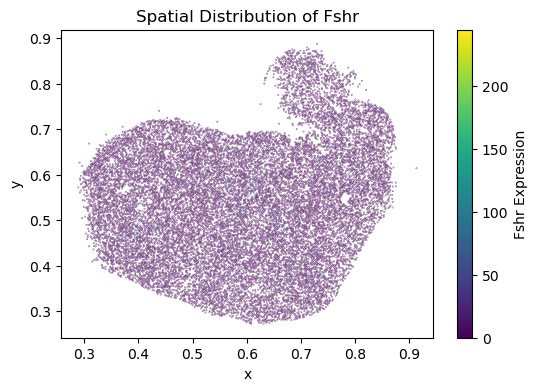

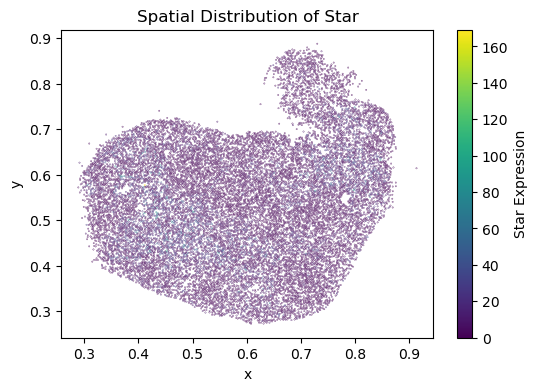

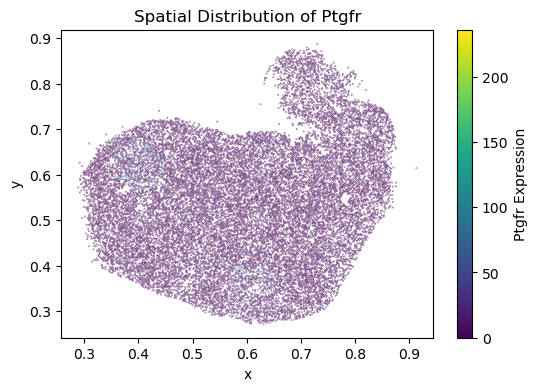

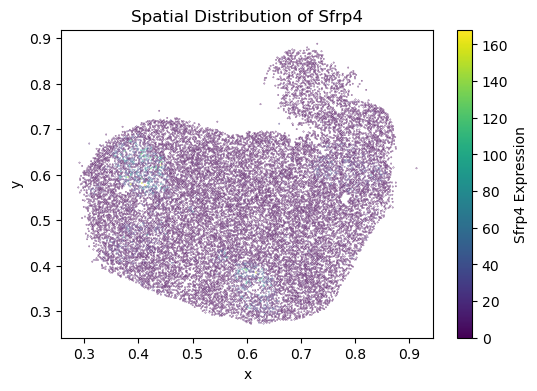

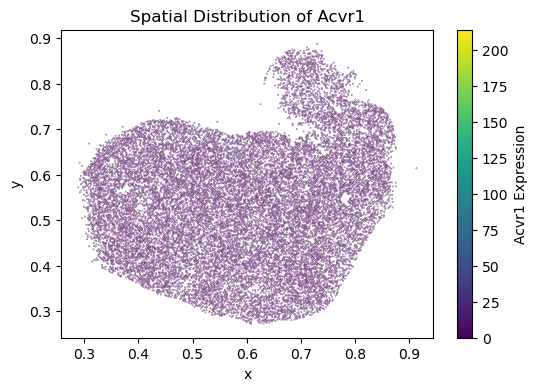

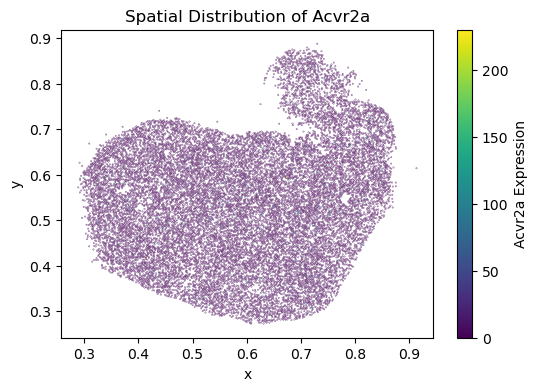

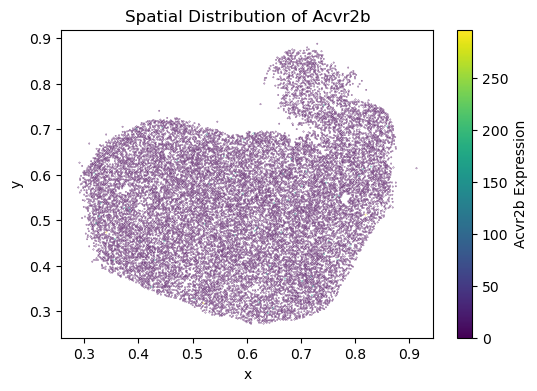

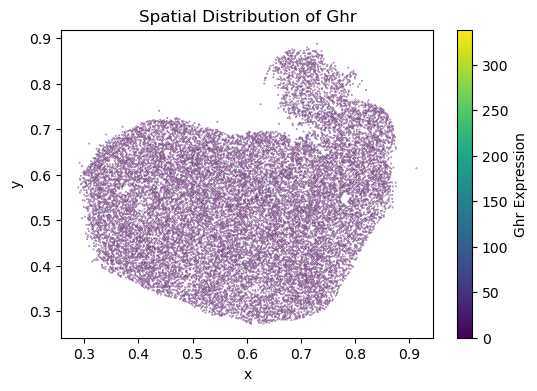

In [20]:
# Plot scatter plots for each gene in gene_list
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    plt.scatter(df['x'], df['y'], c=df[gene], cmap='viridis', s=.05)
    plt.colorbar(label=f'{gene} Expression')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Spatial Distribution of {gene}')
    plt.show()